# tRIBS-Sandbox: 100-Year Frequency Storm

The calibrated model from the previous notebooks was fit to a single observed event. Here we take that same calibrated model — same mesh, soil, land cover, and channel routing — and force it with a synthetic 100-year, 24-hour design storm instead, to see how the watershed would respond to an extreme event it has never actually experienced.

The design storm hyetograph was generated in HEC-HMS and converted to tRIBS's meteorological forcing format ahead of time; the converted files (`precip_Frequency_100yr24hr.mdf`/`.sdf`) are already included in `init_data/met/`. This notebook only builds the new `.in` input file, runs the simulation, and compares the result to the calibration event.

## Imports

In [1]:
# Lets import the pytRIBS project, model, and results classes that we need
from pytRIBS.classes import Project, Model, Results

/Users/cjceders/venvs/pytRIBS_313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, time
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

## Build the Storm Input File

We start from the calibrated model's input file (`SMF.in`) so every calibrated parameter — soil, land cover, mesh, channel routing — carries over unchanged. We only need to override the handful of settings that actually define a storm run:

- **`RUNTIME`**: shortened from 480 hours (the calibration window) to 24 hours (the design storm duration).
- **`INTSTORMMAX`**: raised so the model doesn't reset interstorm/dry-period state partway through the storm.
- **`GAUGESTATIONS`**: swapped from the historical rain gauge record to the synthetic 100-yr storm forcing.
- **`OUTFILENAME`/`OUTHYDROFILENAME`**: redirected to their own `results/FreqStorm_100yr/` subfolder so this run doesn't overwrite the calibration results.

In [3]:
# Load project + the already-calibrated model
name, epsg = 'SMF', 26912
proj = Project(os.getcwd(), name, epsg)
model = Model(input_file='SMF.in',meta=proj.meta)

# Make a dedicated results folder for the storm run
Path('results/FreqStorm_100yr').mkdir(parents=True, exist_ok=True)

# Override only what changes for the design storm
model.runtime['value'] = 24
model.gaugestations['value'] = '../init_data/met/precip_Frequency_100yr24hr.sdf'
model.outfilename['value'] = 'results/FreqStorm_100yr/SMF'

model.write_input_file('FreqStorm_100yr.in')

## Run the Storm Simulation

In [ ]:
# Define File Names
input_filename = 'FreqStorm_100yr.in'
log_filename   = 'freqstorm_simulation.log'

# Pre-run check
# Check if the input file actually exists before trying to run.
if not os.path.exists(input_filename):
    print(f"ERROR: Could not find input file: '{input_filename}'")
    print("Please run the previous cell to build it first.")
else:
    print(f"Found input file: {input_filename}")
    print(f"Starting tRIBS simulation...")
    print(f"Runtime output is being redirected to: {log_filename}")

    # Execute model
    # We use the 'time' module to track how long the simulation takes.
    start_time = time.time()

    # Run tRIBS!
    # syntax: !tRIBS <input_file> > <log_file> 2>&1
    exit_code = os.system(f"tRIBS {input_filename} > {log_filename} 2>&1")

    end_time = time.time()
    duration = (end_time - start_time) / 60

    # Post-run report
    if exit_code == 0:
        print(f"\nSUCCESS: Simulation completed in {duration:.2f} minutes.")

## Compare Results: Calibration Event vs. Design Storm

The calibration run's peak occurs partway through its 480-hour window (the observed August 2014 event), while the storm run's peak occurs somewhere in its own 24-hour window, on absolute calendar time the two peaks don't land anywhere near each other. Instead of comparing on calendar time, we shift the storm hydrograph so its peak lines up with the calibration peak, which makes the shape and magnitude of the two responses more comparable.

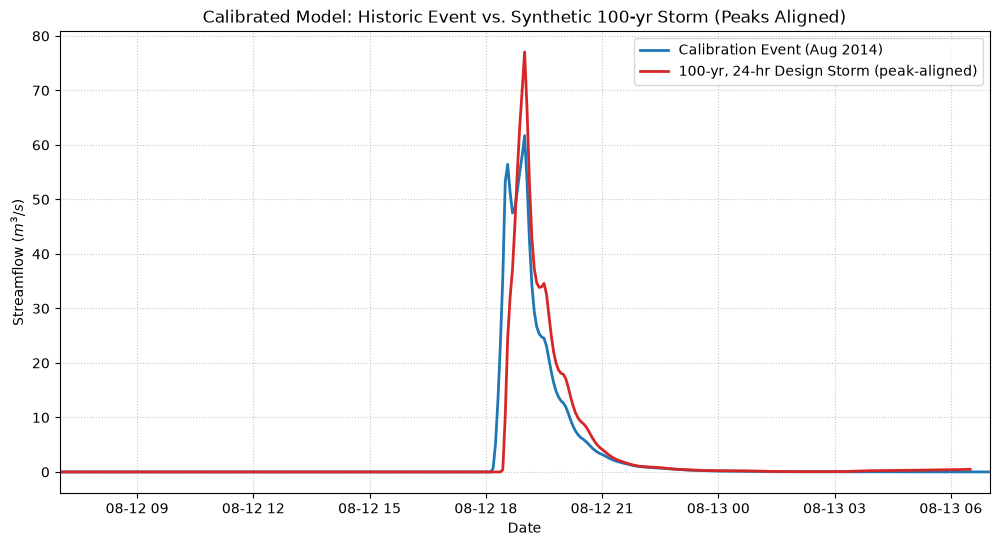

In [4]:
# Load both sets of results
results_calibration = Results('SMF.in', meta=proj.meta)
results_storm = Results('FreqStorm_100yr.in', meta=proj.meta)

calib_qout = results_calibration.get_qout_results()
storm_qout = results_storm.get_qout_results()

# Shift the storm hydrograph in time so its peak lines up with the calibration peak
calib_peak_time = calib_qout.loc[calib_qout['Qstrm_m3s'].idxmax(), 'Time']
storm_peak_time = storm_qout.loc[storm_qout['Qstrm_m3s'].idxmax(), 'Time']
storm_qout = storm_qout.copy()
storm_qout['Time'] = storm_qout['Time'] + (calib_peak_time - storm_peak_time)

# Plot both hydrographs on the same axes
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(calib_qout['Time'], calib_qout['Qstrm_m3s'], label='Calibration Event (Aug 2014)', color='#1f77b4', linewidth=2)
ax.plot(storm_qout['Time'], storm_qout['Qstrm_m3s'], label='100-yr, 24-hr Design Storm (peak-aligned)', color='#d62728', linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('Streamflow ($m^3/s$)')
ax.set_title('Calibrated Model: Historic Event vs. Synthetic 100-yr Storm (Peaks Aligned)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

# Trim the x-axis to a window around the event; adjust these to zoom in/out
plot_start = calib_peak_time - pd.Timedelta(hours=12)
plot_end   = calib_peak_time + pd.Timedelta(hours=12)
ax.set_xlim(plot_start, plot_end)

plt.show()